# Assignment 1 - Exploratory Data Analysis (EDA)

**Student:** Afek Klein
**Course:** Introduction to Data Science
**Dataset:** Football Matches 2024/2025 - Top 5 European Leagues and UEFA Champions League  
**Source:** GitHub repository by Tarek Masryo (Original data: football-data.org API)

This notebook contains the complete submission. All explanations, headings, variable names, comments, results, and conclusions are written in English, as required.

## 1. Assignment Objective

The purpose of this assignment is to perform a complete exploratory data analysis, from loading the data to writing conclusions. The analysis examines the internal structure of the dataset, data quality, hidden assumptions, limitations, distributions, correlations, categorical relationships, index properties, and possible statistical risks.

## 2. Dataset Selection and Source Description

### 2.1 Dataset Requirements
- Tabular data
- At least 1,000 rows
- At least 10 columns
- Numerical, categorical, and time variables
- Source, collection purpose, collector, and domain knowledge

### 2.2 Data Source Description

The dataset used in this assignment is **Football Matches Dataset 2025 - Top 5 Leagues and Champions League**.

The dataset is documented in the author's GitHub repository and is also published on Kaggle. According to the documentation, the original match data was collected from the **football-data.org API** and organised into a clean table for analysis.

The dataset contains **1,941 matches** from the **2024/2025** season in the Premier League, La Liga, Serie A, Bundesliga, Ligue 1, and the UEFA Champions League. It includes **23 columns** with numerical, categorical, and time variables.

The main purpose of the dataset is to provide organised football match data for exploratory data analysis, statistics, visualisation, and machine learning.

The dataset was prepared and published by **Tarek Masryo**, while the original match information comes from the **football-data.org API**.

The GitHub repository explains where the data came from, but it does not describe every step that was used to prepare the dataset. Because of this, some information about the data preparation process is unknown.

I chose this dataset because I enjoy watching football and I am familiar with the game. My background knowledge helped me understand the variables, interpret the results, and identify whether the data looked reasonable and consistent.

The column names are clear and descriptive. For example, **total_goals** represents the total number of goals in a match, **goal_difference** represents the difference between the home and away scores, and **match_outcome** indicates whether the match ended with a home win, draw, or away win.

In [5]:
# Import the libraries required for the analysis
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Display all columns and format decimal values clearly
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 3. Meta-Analysis of the Data

### 3.1 File Analysis

### Assignment requirements addressed
- File size, format, and available file date
- Number of rows and columns
- Column names and data types
- Discussion of whether the data was collected for research or operations
- Possible biases

In [6]:
from datetime import datetime

# Load the dataset and display basic file metadata
DATA_PATH = Path("football_matches_2024_2025.csv")

football = pd.read_csv(DATA_PATH)

file_size_mb = DATA_PATH.stat().st_size / (1024 ** 2)

creation_date = datetime.fromtimestamp(DATA_PATH.stat().st_birthtime)

print(f"File creation date: {creation_date:%Y-%m-%d}")
print(f"File format: {DATA_PATH.suffix}")
print(f"File size: {file_size_mb:.3f} MB")
print(f"Number of rows: {football.shape[0]:,}")
print(f"Number of columns: {football.shape[1]}")


File creation date: 2025-11-08
File format: .csv
File size: 0.309 MB
Number of rows: 1,941
Number of columns: 23


### 3.2 Data Structure

This section presents the number of rows and columns, column names, data types, and the main observations about the structure of the dataset.

In [5]:
# Display column names, data types, non-null counts, and memory usage
football.info()

column_types = football.dtypes.to_frame("data_type")

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   competition_code  1941 non-null   str  
 1   competition_name  1941 non-null   str  
 2   season            1941 non-null   str  
 3   match_id          1941 non-null   int64
 4   matchday          1941 non-null   int64
 5   stage             1941 non-null   str  
 6   status            1941 non-null   str  
 7   date_utc          1941 non-null   str  
 8   referee           1941 non-null   str  
 9   home_team_id      1941 non-null   int64
 10  home_team         1941 non-null   str  
 11  away_team_id      1941 non-null   int64
 12  away_team         1941 non-null   str  
 13  fulltime_home     1941 non-null   int64
 14  fulltime_away     1941 non-null   int64
 15  halftime_home     1941 non-null   int64
 16  halftime_away     1941 non-null   int64
 17  goal_difference   1941 non-null   int64
 18 

### 3.2 Data Structure - Interpretation

The dataset contains **1,941 rows** and **23 columns**, which is sufficient for exploratory data analysis.

The column names are clear and descriptive.

The dataset contains different data types:

- Integer variables are mainly used for scores, points, and identifiers.
- Object variables are used for categorical information such as team names, competitions, referees, and the `date_utc` column.
- The `date_utc` column is stored as a string (`object`) when the dataset is loaded and is later converted to the `datetime` type before performing time-based analysis.

The data appears to have been collected for operational purposes because it records the results of real football matches.

Possible sources of bias include:
- The dataset contains only one football season.
- Only the five major European leagues and the UEFA Champions League are included.
- Different competitions contain different numbers of matches.
- The results may not represent football competitions outside Europe or other seasons.

## Data Preparation and Feature Creation



Before starting the analysis, the date column was converted from text to a datetime variable.

Several new variables were created for later parts of the assignment:

- `month_number` was created for monthly analysis.
- `weekday` was created for categorical frequency analysis.
- `halftime_total_goals` was created to compare half-time goals with full-time goals.
- `goal_band` was created by dividing the total number of goals into groups. This variable is used for the required binning analysis.

These variables are based on existing columns and do not change the original match results.

In [57]:
# Convert the date column from text to datetime
football["date_utc"] = pd.to_datetime(football["date_utc"],utc=True)

# Create time variables for later analysis
football["month_number"] = football["date_utc"].dt.month
football["weekday"] = football["date_utc"].dt.day_name()

# Calculate the total number of goals at half-time
football["halftime_total_goals"] = (football["halftime_home"]+ football["halftime_away"])

# Divide total goals into groups for categorical analysis
football["goal_band"] = pd.cut(football["total_goals"],bins=[-1, 1, 3, 5, float("inf")],labels=["0-1", "2-3", "4-5", "6+"])

football.head()

,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id,month_number,weekday,halftime_total_goals,goal_band
0,PL,Premier League,2024/2025,497410,1,REGULAR_SEASON,FINISHED,2024-08-16 19:00:00+00:00,Robert Jones,66,Manchester United FC,63,Fulham FC,1,0,0,0,1,1,Home Win,3,0,1,8,Friday,0,0-1
1,PL,Premier League,2024/2025,497411,1,REGULAR_SEASON,FINISHED,2024-08-17 11:30:00+00:00,Tim Robinson,349,Ipswich Town FC,64,Liverpool FC,0,2,0,0,-2,2,Away Win,0,3,2,8,Saturday,0,2-3
2,PL,Premier League,2024/2025,497412,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Jarred Gillett,57,Arsenal FC,76,Wolverhampton Wanderers FC,2,0,1,0,2,2,Home Win,3,0,3,8,Saturday,1,2-3
3,PL,Premier League,2024/2025,497413,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Simon Hooper,62,Everton FC,397,Brighton & Hove Albion FC,0,3,0,1,-3,3,Away Win,0,3,4,8,Saturday,1,2-3
4,PL,Premier League,2024/2025,497414,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Craig Pawson,67,Newcastle United FC,340,Southampton FC,1,0,1,0,1,1,Home Win,3,0,5,8,Saturday,1,0-1


### 4.1 Missing Data

The assignment requires evaluating the amount and pattern of missing data, what can be learned from the missingness, and how the values would be completed.

In [5]:
# Count missing values in every column
missing_summary = pd.DataFrame({"missing_count": football.isna().sum(),"missing_percentage": football.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percentage
competition_code,0,0.000
competition_name,0,0.000
season,0,0.000
match_id,0,0.000
matchday,0,0.000
stage,0,0.000
status,0,0.000
date_utc,0,0.000
referee,0,0.000
home_team_id,0,0.000



No missing values were found in the dataset. Therefore:
- There is no missingness pattern to classify as random or structured.
- The complete coverage may indicate that the dataset was cleaned before publication.


### 4.2 Complete and Partial Duplicates

In [6]:
# Check complete duplicates and partial duplicates representing the same match
complete_duplicates = football.duplicated().sum()

partial_duplicates = football.duplicated(subset=["date_utc", "home_team", "away_team"]).sum()

print(f"Complete duplicates: {complete_duplicates}")
print(f"Partial match duplicates: {partial_duplicates}")
print(f"Unique match IDs: {football['match_id'].nunique():,}")
print(f"Total rows: {len(football):,}")

Complete duplicates: 0
Partial match duplicates: 0
Unique match IDs: 1,941
Total rows: 1,941


No complete duplicates and no partial match duplicates were found. The `match_id` column is also unique for all rows. Therefore, no observations should be removed as duplicates.

Matches occurring at the same time are not necessarily duplicates, because several competitions may schedule matches simultaneously.

### 4.3 Suspicious and Impossible Values

The checks below examine negative scores, half-time scores greater than final scores, inconsistent derived variables, invalid points, invalid outcomes, and common placeholder values.

In [12]:
# Build the expected points from the final score
expected_home_points = np.select(
    [football["fulltime_home"] > football["fulltime_away"],football["fulltime_home"] == football["fulltime_away"]],
    [3, 1],default=0)

expected_away_points = np.select(
    [football["fulltime_away"] > football["fulltime_home"],football["fulltime_away"] == football["fulltime_home"]],
    [3, 1],default=0)

# Search for common textual placeholder values
placeholder_values = {"", "-", "n/a", "na", "none", "null", "unknown", "tbd"}
text_columns = football.select_dtypes(include=["object", "string"]).columns

placeholder_count = sum(football[column].astype("string").str.strip().str.lower().isin(placeholder_values).sum()
    for column in text_columns)

suspicious_checks = {
    "negative_fulltime_home": (football["fulltime_home"] < 0).sum(),
    "negative_fulltime_away": (football["fulltime_away"] < 0).sum(),
    "negative_halftime_home": (football["halftime_home"] < 0).sum(),
    "negative_halftime_away": (football["halftime_away"] < 0).sum(),
    "halftime_home_above_fulltime": (football["halftime_home"] > football["fulltime_home"]).sum(),
    "halftime_away_above_fulltime": (football["halftime_away"] > football["fulltime_away"]).sum(),
    "incorrect_total_goals": (football["total_goals"]!= football["fulltime_home"] + football["fulltime_away"]).sum(),
    "incorrect_goal_difference": (football["goal_difference"]!= football["fulltime_home"] - football["fulltime_away"]).sum(),
    "incorrect_home_points": (football["home_points"].to_numpy() != expected_home_points).sum(),
    "incorrect_away_points": (football["away_points"].to_numpy() != expected_away_points).sum(),
    "invalid_match_outcome": (~football["match_outcome"].isin(["Home Win", "Draw", "Away Win"])).sum(),
    "placeholder_text_values": placeholder_count
}

pd.Series(suspicious_checks, name="number_of_issues")

negative_fulltime_home          0
negative_fulltime_away          0
negative_halftime_home          0
negative_halftime_away          0
halftime_home_above_fulltime    0
halftime_away_above_fulltime    0
incorrect_total_goals           0
incorrect_goal_difference       0
incorrect_home_points           0
incorrect_away_points           0
invalid_match_outcome           0
placeholder_text_values         3
Name: number_of_issues, dtype: int64


No logical inconsistencies were found. Zero goals are valid in football and should not be treated as suspicious. High-scoring matches are unusual but possible, so they should be examined as outliers rather than automatically removed.

### 4.4 Cardinality

Cardinality is the number of unique values in each column.

In [10]:
# Count unique values in every column
cardinality = football.nunique(dropna=False).sort_values()
cardinality.to_frame("unique_values")


,unique_values
season,1
status,2
home_points,3
match_outcome,3
away_points,3
competition_code,6
competition_name,6
halftime_away,6
stage,7
halftime_home,7



- `season` has one value only and therefore has no variation inside this dataset.
- `match_id` is unique for every observation and is suitable as a record identifier.
- Team names and referees are high-cardinality categorical variables.
- Identifier columns contain many unique integers, but their numerical magnitude has no analytical meaning.
- Rare referees or stages may still contain valid information and should not be removed automatically.

## 5. Univariate Analysis

### 5.1 Numerical Variables

The assignment requires mean, median, standard deviation, MAD, minimum, maximum, quantiles, IQR, skewness, distributions, and three one-dimensional outlier methods.

In [33]:
# Select numerical variables with analytical meaning
numerical_columns = [
    "fulltime_home",
    "fulltime_away",
    "halftime_home",
    "halftime_away",
    "goal_difference",
    "total_goals",
    "home_points",
    "away_points"
]

descriptive_statistics = football[numerical_columns].describe().T

descriptive_statistics["median"] = football[numerical_columns].median()
descriptive_statistics["MAD"] = football[numerical_columns].apply(lambda series: np.median(np.abs(series - np.median(series))))
descriptive_statistics["IQR"] = (descriptive_statistics["75%"] - descriptive_statistics["25%"])
descriptive_statistics["skewness"] = football[numerical_columns].skew()

descriptive_statistics

,count,mean,std,min,25%,50%,75%,max,median,MAD,IQR,skewness
fulltime_home,"1,941.000",1.536,1.323,0.000,1.000,1.000,2.000,9.000,1.000,1.000,1.000,1.045
fulltime_away,"1,941.000",1.340,1.206,0.000,0.000,1.000,2.000,7.000,1.000,1.000,2.000,0.991
halftime_home,"1,941.000",0.700,0.860,0.000,0.000,1.000,1.000,6.000,1.000,1.000,1.000,1.416
halftime_away,"1,941.000",0.588,0.790,0.000,0.000,0.000,1.000,5.000,0.000,0.000,1.000,1.485
goal_difference,"1,941.000",0.196,1.881,-6.000,-1.000,0.000,1.000,8.000,0.000,1.000,2.000,0.046
total_goals,"1,941.000",2.876,1.694,0.000,2.000,3.000,4.000,11.000,3.000,1.000,2.000,0.547
home_points,"1,941.000",1.524,1.332,0.000,0.000,1.000,3.000,3.000,1.000,1.000,3.000,0.069
away_points,"1,941.000",1.237,1.306,0.000,0.000,1.000,3.000,3.000,1.000,1.000,3.000,0.454


The mean and median of `total_goals` are similar, so they describe the data well. The positive skewness shows that a few matches with many goals increase the average. The median and IQR are useful because they are less affected by extreme values. Identifier columns should not be analysed with averages, and `total_goals` and `goal_difference` are calculated from the final scores.

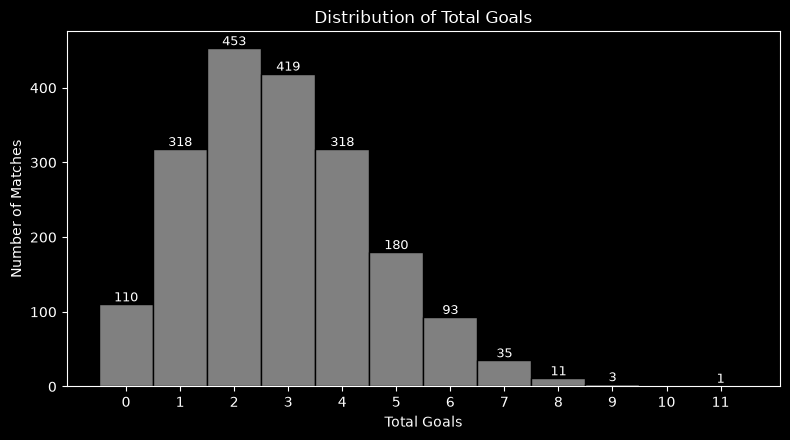

In [49]:
# Histogram of total goals
plt.figure(figsize=(8, 4.5))

counts, bins, patches = plt.hist(football["total_goals"],bins=np.arange(-0.5, football["total_goals"].max() + 1.5, 1),
    edgecolor="black",facecolor="gray")

# Add the exact count above each bar
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(patch.get_x() + patch.get_width() / 2,count,f"{int(count)}",ha="center",va="bottom",fontsize=9)

plt.title("Distribution of Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.xticks(range(0, football["total_goals"].max() + 1))
plt.tight_layout()
plt.show()


Most matches contain a low or moderate number of goals. A small number of matches contain many goals, producing a longer right tail. These high values increase the mean, although the difference between the mean and median is small.

In [54]:
# Detect one-dimensional outliers using three required methods
def count_outliers(series):
    """Count outliers using IQR, Z-score, and Modified Z-score methods."""

    clean_series = series.dropna()
    # IQR method:
    # Values outside Q1 - 1.5×IQR and Q3 + 1.5×IQR are considered outliers.
    first_quartile, third_quartile = clean_series.quantile([0.25, 0.75])
    interquartile_range = third_quartile - first_quartile

    iqr_mask = (
        (clean_series < first_quartile - 1.5 * interquartile_range)
        | (clean_series > third_quartile + 1.5 * interquartile_range))

    # Z-score method:
    # Values with |Z-score| greater than 3 are considered outliers.
    # The threshold of 3 standard deviations is the standard statistical rule.
    z_score_mask = np.abs(stats.zscore(clean_series, nan_policy="omit")) > 3

    # Modified Z-score method:
    # Values with |Modified Z-score| greater than 3.5 are considered outliers.
    # The threshold of 3.5 is commonly used because this method is more robust to extreme values.
    median = np.median(clean_series)
    median_absolute_deviation = np.median(np.abs(clean_series - median))


    if median_absolute_deviation == 0:
        modified_z_mask = np.zeros(len(clean_series), dtype=bool)
    else:
        # The constant 0.6745 scales the Modified Z-score so it is comparable to the standard Z-score for normally distributed data.
        modified_z_scores = (0.6745 * (clean_series - median) / median_absolute_deviation)
        modified_z_mask = np.abs(modified_z_scores) > 3.5

    return {
        "IQR": int(iqr_mask.sum()),
        "Z-score": int(z_score_mask.sum()),
        "Modified Z-score": int(modified_z_mask.sum())
    }


outlier_columns = ["fulltime_home","fulltime_away","goal_difference","total_goals"]

outlier_results = pd.DataFrame({column: count_outliers(football[column]) for column in outlier_columns}).T

outlier_results.index.name = "variable"
outlier_results

,IQR,Z-score,Modified Z-score
variable,,,
fulltime_home,164,15,10
fulltime_away,10,36,1
goal_difference,45,17,17
total_goals,15,15,4



The three methods identify different numbers of outliers because they use different assumptions:
- IQR is based on quartiles and does not require normality.
- Z-score is based on the mean and standard deviation.
- Modified Z-score is based on the median and MAD and is more robust.

The counts should not be added because the same observation may be identified by more than one method. In football, a high score may be rare but valid, so the outliers are retained rather than deleted automatically.

#### 5.2 Parameter Selection

The assignment requires analysing the Top-K categories, determining the minimum number of categories required to cover P% of the data, and identifying rare categories. Since the assignment does not specify numerical values for these parameters, the following values were selected for this analysis:

- **K = 5** (Top 5 most frequent categories)
- **P = 80%** (Minimum categories required to describe at least 80% of the observations)
- **Rare category threshold = 1%** of the dataset

These values were chosen to provide a clear and interpretable summary of the categorical variables and can be adjusted if different thresholds are required.


In [68]:
K = 5
P = 80
RARE_THRESHOLD = 1

categorical_columns = ["match_outcome","competition_name","stage","weekday","referee"]

for column in categorical_columns:
    counts = football[column].value_counts()
    percentages = football[column].value_counts(normalize=True) * 100

    print(f"\n=============Variable: {column}=============")

    # Most common value
    print("Most common:",counts[counts == counts.max()].index.tolist(),f"({percentages.iloc[0]:.2f}%)")

    # Top K values with the highest percentages
    top_k = percentages.head(K)

    print(f"\nTop {K} values:")
    print(top_k.round(2))

    print(f"Top {K} total percentage: {top_k.sum():.2f}%"
    )

    # Minimum values required to cover at least P percent
    cumulative = percentages.cumsum()
    minimum_number = (cumulative >= P).argmax() + 1
    coverage_values = percentages.index[:minimum_number].tolist()

    print(f"\nValues required to cover at least {P}%:")
    print(coverage_values)

    # Rare categories
    rare_categories = percentages[percentages < RARE_THRESHOLD]

    if not rare_categories.empty:
        print("\nRare categories:")
        print(rare_categories.round(2))


=============Variable: match_outcome=============
Most common: ['Home Win'] (42.86%)

Top 5 values:
match_outcome
Home Win   42.860
Away Win   33.280
Draw       23.850
Name: proportion, dtype: float64
Top 5 total percentage: 100.00%

Values required to cover at least 80%:
['Home Win', 'Away Win', 'Draw']

=============Variable: competition_name=============
Most common: ['Premier League', 'La Liga', 'Serie A'] (19.58%)

Top 5 values:
competition_name
Premier League   19.580
La Liga          19.580
Serie A          19.580
Bundesliga       15.770
Ligue 1          15.770
Name: proportion, dtype: float64
Top 5 total percentage: 90.26%

Values required to cover at least 80%:
['Premier League', 'La Liga', 'Serie A', 'Bundesliga', 'Ligue 1']

=============Variable: stage=============
Most common: ['REGULAR_SEASON'] (90.26%)

Top 5 values:
stage
REGULAR_SEASON   90.260
LEAGUE_STAGE      7.420
PLAYOFFS          0.820
LAST_16           0.820
QUARTER_FINALS    0.410
Name: proportion, dtype: floa


For `match_outcome`, the most common category is a home win, but it does not represent a majority of all matches. Therefore, the mode alone is not sufficient, and the full percentage distribution should also be reported.

For `competition_name`, all six competitions are meaningful and should remain separate. They should not be merged into `"Other"`.

For high-cardinality variables such as `referee`, many categories may be rare. Rare referees are still valid and potentially informative. They may be grouped only for a compact chart or predictive model when individual identity is not important.

The mode represents a categorical variable well only when one category clearly dominates. When several categories have similar frequencies, frequency tables and cumulative coverage provide a more complete description.

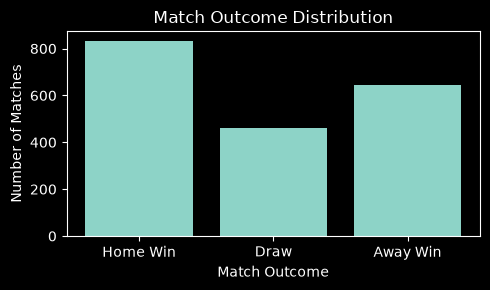

In [70]:
# Bar chart for match-outcome frequencies
outcome_order = ["Home Win", "Draw", "Away Win"]
outcome_counts = (football["match_outcome"].value_counts().reindex(outcome_order))

plt.figure(figsize=(5, 3))
plt.bar(outcome_order, outcome_counts.values)
plt.title("Match Outcome Distribution")
plt.xlabel("Match Outcome")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()


## 6. Correlations and Relationships
### 6.1 Numerical-Numerical Relationships

The assignment requires Pearson, Spearman, and Kendall correlations, an explanation of their differences, a correlation matrix, scatterplots, and conclusions.

In [73]:
# Calculate the three required correlation matrices
correlation_columns = [
    "fulltime_home",
    "fulltime_away",
    "halftime_home",
    "halftime_away",
    "goal_difference",
    "total_goals"
]

pearson_correlation = football[correlation_columns].corr(method="pearson")
spearman_correlation = football[correlation_columns].corr(method="spearman")
kendall_correlation = football[correlation_columns].corr(method="kendall")

print("Pearson correlation:")
display(pearson_correlation)

print("Spearman correlation:")
display(spearman_correlation)

print("Kendall correlation:")
display(kendall_correlation)

Pearson correlation:


,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals
fulltime_home,1.000,-0.105,0.700,-0.050,0.770,0.706
fulltime_away,-0.105,1.000,-0.041,0.683,-0.715,0.630
halftime_home,0.700,-0.041,1.000,-0.035,0.519,0.517
halftime_away,-0.050,0.683,-0.035,1.000,-0.473,0.447
goal_difference,0.770,-0.715,0.519,-0.473,1.000,0.093
total_goals,0.706,0.630,0.517,0.447,0.093,1.000


Spearman correlation:


,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals
fulltime_home,1.000,-0.082,0.676,-0.032,0.751,0.677
fulltime_away,-0.082,1.000,-0.035,0.647,-0.686,0.628
halftime_home,0.676,-0.035,1.000,-0.045,0.493,0.478
halftime_away,-0.032,0.647,-0.045,1.000,-0.422,0.437
goal_difference,0.751,-0.686,0.493,-0.422,1.000,0.080
total_goals,0.677,0.628,0.478,0.437,0.080,1.000


Kendall correlation:


,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals
fulltime_home,1.000,-0.068,0.611,-0.027,0.654,0.586
fulltime_away,-0.068,1.000,-0.030,0.593,-0.591,0.537
halftime_home,0.611,-0.030,1.000,-0.041,0.421,0.411
halftime_away,-0.027,0.593,-0.041,1.000,-0.364,0.377
goal_difference,0.654,-0.591,0.421,-0.364,1.000,0.062
total_goals,0.586,0.537,0.411,0.377,0.062,1.000


- Pearson measures linear relationships between numerical variables.
- Spearman measures relationships based on the ranking of the values, so it is less affected by extreme values.
- Kendall also uses rankings and usually gives more conservative results.

A high correlation does not always mean that one variable affects the other. In this dataset, some correlations are expected because some variables are calculated from others. For example:

- `total_goals = fulltime_home + fulltime_away`
- `goal_difference = fulltime_home - fulltime_away`

Therefore, these high correlations are expected and do not necessarily indicate a real relationship between independent variables.

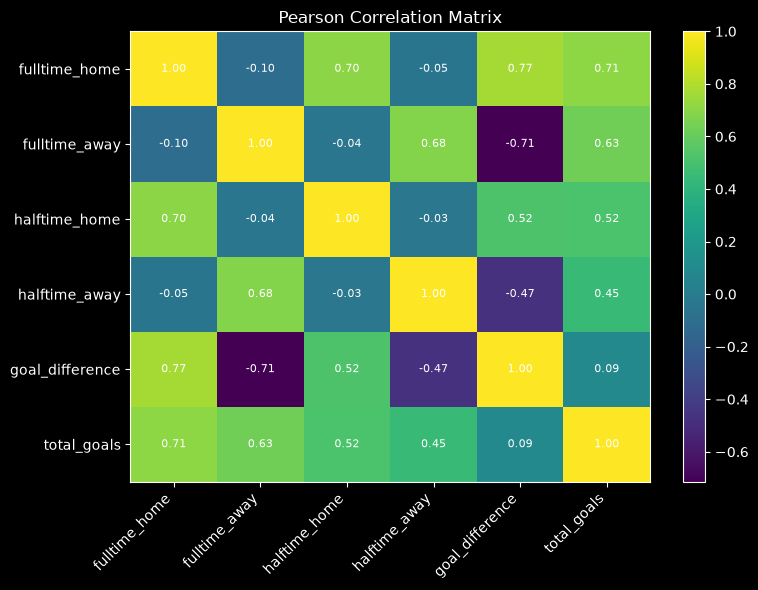

In [75]:
# Pearson correlation heatmap
plt.figure(figsize=(8, 6))
image = plt.imshow(pearson_correlation.values, aspect="auto")
plt.colorbar(image)

plt.xticks(range(len(correlation_columns)),correlation_columns,rotation=45,ha="right")
plt.yticks(range(len(correlation_columns)),correlation_columns)

for row_index in range(pearson_correlation.shape[0]):
    for column_index in range(pearson_correlation.shape[1]):
        plt.text(
            column_index,
            row_index,
            f"{pearson_correlation.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

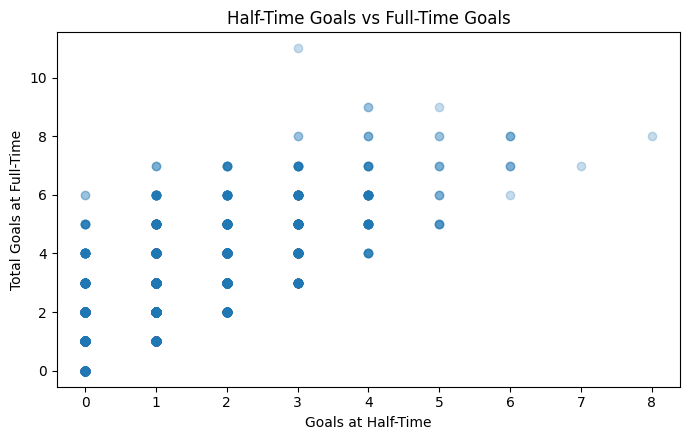

,halftime_total_goals,total_goals
halftime_total_goals,1.000,0.695
total_goals,0.695,1.000


In [16]:
# Scatterplot: half-time goals versus full-time goals
plt.figure(figsize=(7, 4.5))
plt.scatter(
    football["halftime_total_goals"],
    football["total_goals"],
    alpha=0.25
)
plt.title("Half-Time Goals vs Full-Time Goals")
plt.xlabel("Goals at Half-Time")
plt.ylabel("Total Goals at Full-Time")
plt.tight_layout()
plt.show()

halftime_final_correlation = football[["halftime_total_goals", "total_goals"]].corr(method="pearson")

halftime_final_correlation


Each point represents one match. The upward pattern shows a positive relationship: matches with more goals by half-time generally finish with more total goals. The relationship is not perfect because the number of second-half goals varies substantially between matches.

### 6.2 Categorical Relationships


In [85]:
# Frequency table between competition and match outcome
competition_outcome_table = pd.crosstab(football["competition_name"],football["match_outcome"])
competition_outcome_percentage = pd.crosstab(football["competition_name"],football["match_outcome"],normalize="index") * 100

print("Frequency table:")
display(competition_outcome_table)

print("Row percentages:")
display(competition_outcome_percentage.round(2).astype(str) + "%")

Frequency table:


match_outcome,Away Win,Draw,Home Win
competition_name,,,
Bundesliga,111,77,118
La Liga,114,97,169
Ligue 1,101,62,143
Premier League,132,93,155
Serie A,121,108,151
UEFA Champions League,67,26,96


Row percentages:


match_outcome,Away Win,Draw,Home Win
competition_name,,,
Bundesliga,36.27%,25.16%,38.56%
La Liga,30.0%,25.53%,44.47%
Ligue 1,33.01%,20.26%,46.73%
Premier League,34.74%,24.47%,40.79%
Serie A,31.84%,28.42%,39.74%
UEFA Champions League,35.45%,13.76%,50.79%


In [84]:
# Optional: Cramer's V
chi_square, _, _, _ = stats.chi2_contingency(competition_outcome_table)

sample_size = competition_outcome_table.to_numpy().sum()

minimum_dimension = min(competition_outcome_table.shape[0] - 1,competition_outcome_table.shape[1] - 1)

cramers_v = math.sqrt(chi_square / (sample_size * minimum_dimension))

print(f"Cramer's V: {cramers_v:.3f}")

# Divide total goals into categories
football["goal_band"] = pd.cut(football["total_goals"],bins=[-1, 1, 3, 5, float("inf")],labels=["0-1", "2-3", "4-5", "6+"])

# Compare goal bands with match outcome
goal_band_outcome_table = pd.crosstab(football["goal_band"],football["match_outcome"],normalize="index") * 100

goal_band_outcome_table.round(2)

Cramer's V: 0.077


match_outcome,Away Win,Draw,Home Win
goal_band,,,
0-1,31.780,25.700,42.520
2-3,34.170,25.690,40.140
4-5,34.140,22.090,43.780
6+,29.370,13.290,57.340


The chi-square test shows that there is a statistical relationship between the competition and the match outcome because the p-value is very small.

However, Cramer's V is low, so the relationship is weak. This means that the competition has only a small effect on the match outcome.

In [86]:
# Compare binned total goals with match outcome
goal_band_outcomes = pd.crosstab(football["goal_band"],football["match_outcome"],normalize="index") * 100
goal_band_outcomes.round(2).astype(str)+'%'

match_outcome,Away Win,Draw,Home Win
goal_band,,,
0-1,31.78%,25.7%,42.52%
2-3,34.17%,25.69%,40.14%
4-5,34.14%,22.09%,43.78%
6+,29.37%,13.29%,57.34%


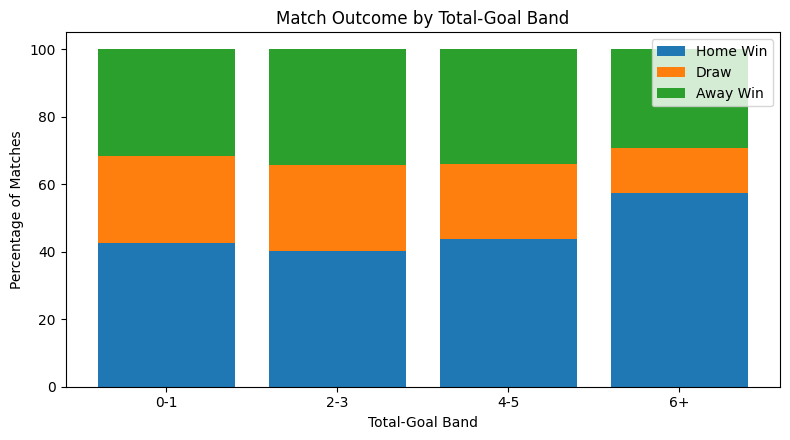

In [20]:
# Stacked percentage bar chart
plot_table = goal_band_outcomes[["Home Win", "Draw", "Away Win"]]
plt.figure(figsize=(8, 4.5))

bottom = np.zeros(len(plot_table))

for outcome in plot_table.columns:
    plt.bar(
        plot_table.index.astype(str),
        plot_table[outcome].values,
        bottom=bottom,
        label=outcome
    )
    bottom += plot_table[outcome].values

plt.title("Match Outcome by Total-Goal Band")
plt.xlabel("Total-Goal Band")
plt.ylabel("Percentage of Matches")
plt.legend()
plt.tight_layout()
plt.show()


Binning converts the numerical `total_goals` variable into ordered categories. Low-scoring matches have a relatively higher draw rate, while high-scoring matches have a lower draw rate and a higher home-win share. The result suggests that match outcome composition changes across goal-volume groups.

### 6.3 Graphs

The notebook includes a histogram, bar charts, a scatterplot, a heatmap, a stacked bar chart, and a time-series line chart. Each graph includes a title and axis labels, followed by a short interpretation of the result.


## 7. Index Analysis

The assignment requires checking whether the index is unique, time-based, sorted, and whether the analysis changes over time.

In [21]:
# Check index and time properties
print("Default index is unique:", football.index.is_unique)
print("Default index type:", type(football.index).__name__)
print("Match ID is unique:", football["match_id"].is_unique)
print("Date is unique:", football["date_utc"].is_unique)
print("Data is sorted chronologically:",football["date_utc"].is_monotonic_increasing)

Default index is unique: True
Default index type: RangeIndex
Match ID is unique: True
Date is unique: False
Data is sorted chronologically: False



The default `RangeIndex` is unique but has no business meaning. The `match_id` column is the best identifier because it is unique for every match.

The date column is time-based but not unique, because multiple matches can start at the same time. The original dataset is not fully sorted by date across all competitions, so it should be explicitly sorted before chronological analysis.

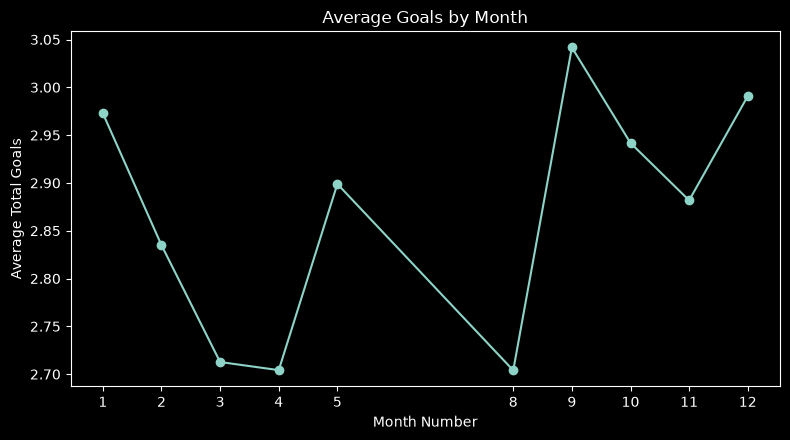

,average_total_goals
date_utc,
1,2.970
2,2.830
3,2.710
4,2.700
5,2.900
8,2.700
9,3.040
10,2.940
11,2.880


In [91]:
# Monthly average goals
monthly_average_goals = (football.set_index("date_utc").resample("ME")["total_goals"].mean())

# Sort by month number
monthly_average_goals = (monthly_average_goals.groupby(monthly_average_goals.index.month).mean().sort_index())

plt.figure(figsize=(8, 4.5))
plt.plot(monthly_average_goals.index,monthly_average_goals.values,marker="o")

plt.title("Average Goals by Month")
plt.xlabel("Month Number")
plt.ylabel("Average Total Goals")
plt.xticks(monthly_average_goals.index)
plt.tight_layout()
plt.show()

monthly_average_goals.round(2).to_frame("average_total_goals")


The average number of goals changes between months. However, one season is insufficient to prove stable seasonality. Monthly differences may be influenced by competition stages, fixture congestion, unequal sample sizes, and changes in the mixture of teams and competitions.

## 8. Insights and Data Story

### Main insights

1. **Home advantage**

   Home teams scored more goals and won more matches than away teams. This suggests that playing at home gives teams an advantage.

2. **Goal distribution**

   Most matches ended with 2-3 goals, while only a few matches had many goals. Because of these extreme matches, it is useful to examine the median and IQR in addition to the mean.

3. **Differences between competitions**

   The average number of goals and the distribution of match outcomes were not exactly the same in every competition. This indicates that different competitions have different playing characteristics.

4. **Data quality**

   The dataset contained no missing values, duplicate matches, or obvious logical errors. This made it suitable for statistical analysis.

5. **Categorical variables**

   Some variables, such as `match_outcome`, contain only a few categories, while variables such as `referee` contain many different values. Some referee categories appear only a few times, but they still represent valid data.

### Biases and limitations

- The dataset includes only one football season.
- Only the major European competitions are included.
- Different competitions contain different numbers of matches.
- The results may not represent football in other leagues or seasons.
- The original data source does not fully describe how the data was collected.

### Possible analysis risks

- Treating identifier columns (such as `match_id`) as numerical variables.
- Using variables that were calculated from other variables, which can create misleading results.
- Removing rare but valid categories without checking their importance.
- Assuming that a statistically significant result always means a strong practical relationship.
- Applying the conclusions to other seasons without additional analysis.

### What I learned

This analysis showed that a dataset can be clean and consistent while still having limitations. It also showed the importance of checking the quality of the data, choosing suitable statistical methods, and interpreting the results based on the structure of the dataset rather than only on numerical outputs.

## 9. Bonus

In [92]:
# Bonus: compare home and away goals using parametric and non-parametric tests
paired_t_test = stats.ttest_rel(football["fulltime_home"],football["fulltime_away"])

wilcoxon_test = stats.wilcoxon(football["fulltime_home"],football["fulltime_away"],zero_method="wilcox")

print("Home vs Away Goals")
print("-" * 45)
print(f"Mean home goals: {football['fulltime_home'].mean():.3f}")
print(f"Mean away goals: {football['fulltime_away'].mean():.3f}")
print(f"Paired t-test p-value: {paired_t_test.pvalue:.3e}")
print(f"Wilcoxon p-value: {wilcoxon_test.pvalue:.3e}")

Home vs Away Goals
--------------------
Mean home goals: 1.536
Mean away goals: 1.340
Paired t-test p-value: 4.801e-06
Wilcoxon p-value: 5.743e-06


### Home-Advantage Test - Interpretation

Both tests produce very small p-values, indicating that home and away goal values differ statistically in this dataset. The home-goal mean is higher. The Wilcoxon result supports the same conclusion without requiring normality.

In [24]:
# Bonus: compare total goals across competitions
competition_goal_groups = [group["total_goals"].dropna().to_numpy()
    for _, group in football.groupby("competition_name")]

anova_test = stats.f_oneway(*competition_goal_groups)
kruskal_test = stats.kruskal(*competition_goal_groups)

alpha = 0.05

print("Comparison of Total Goals Across Competitions")
print("-" * 55)

print("\nANOVA")
print(f"F-statistic: {anova_test.statistic:.3f}")
print(f"P-value: {anova_test.pvalue:.3e}")
print("Conclusion: "+ ("At least one competition has a different mean number of goals."
        if anova_test.pvalue < alpha
        else "No significant mean difference was found."))

print("\nKruskal-Wallis")
print(f"H-statistic: {kruskal_test.statistic:.3f}")
print(f"P-value: {kruskal_test.pvalue:.3e}")
print("Conclusion: "+ ("At least one competition has a different goal distribution."
        if kruskal_test.pvalue < alpha
        else "No significant distributional difference was found."))

Comparison of Total Goals Across Competitions
-------------------------------------------------------

ANOVA
F-statistic: 8.993
P-value: 1.844e-08
Conclusion: At least one competition has a different mean number of goals.

Kruskal-Wallis
H-statistic: 39.878
P-value: 1.581e-07
Conclusion: At least one competition has a different goal distribution.


### Competition Tests - Interpretation

Both ANOVA and Kruskal-Wallis reject the null hypothesis. Therefore, at least one competition differs from the others in mean or distribution of total goals.

These omnibus tests do not identify which specific competition pairs differ. A post-hoc procedure would be required for pairwise conclusions.

### Proposals for Further Research

- Add multiple seasons to test whether the findings are stable over time.
- Add expected-goals, shots, possession, cards, line-ups, and injuries.
- Examine rest days and fixture congestion.
- Compare domestic leagues and knockout competitions separately.
